# WISDM Human Activity Recognition

Import the libraries used in this notebook.


In [1]:
from pathlib import Path

import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

Set the data folder, the map from activity letter to name, and the lists of devices and sensors.


In [2]:
DATA_DIR = Path("data/wisdm-dataset")

RAW_DATA_DIR = DATA_DIR / "raw"

ACTIVITY_MAP = {
    "A": "walking",
    "B": "jogging",
    "C": "stairs",
    "D": "sitting",
    "E": "standing",
    "F": "typing",
    "G": "teeth",
    "H": "soup",
    "I": "chips",
    "J": "pasta",
    "K": "drinking",
    "L": "sandwich",
    "M": "kicking",
    "O": "catch",
    "P": "dribbling",
    "Q": "writing",
    "R": "clapping",
    "S": "folding",
}

ACTIVITIES = list(ACTIVITY_MAP.keys())

DEVICES = (
    "phone",
    "watch",
)
SENSORS = (
    "accel",
    "gyro",
)
COLUMNS = ["id", "activity", "timestamp", "x", "y", "z"]

Read all 204 raw files into one table `df`, removing the `;` at the end of each line.
The table is saved as a CSV cache, so the next run loads it much faster.
Subject 1629's files contain every row twice, so the copies are removed.


In [3]:
CACHE_PATH = Path("data/processed/all_data.csv")
RAW_DTYPES = {"id": "int16", "timestamp": "int64", "x": "float32", "y": "float32"}


def load_file_to_frame(file_path: Path, device: str, sensor: str) -> pd.DataFrame:
    df = pd.read_csv(
        file_path, header=None, names=COLUMNS, dtype={**RAW_DTYPES, "z": "str"}
    )
    df["z"] = df["z"].str.rstrip(";").astype("float32")  # drop the trailing ';' in bulk
    df["sensor"], df["device"] = sensor, device
    return df


def load_data() -> pd.DataFrame:
    frames = [
        load_file_to_frame(path, device, sensor)
        for device in DEVICES
        for sensor in SENSORS
        for path in sorted((RAW_DATA_DIR / device / sensor).glob("data_*.txt"))
    ]
    all_df = pd.concat(frames, ignore_index=True)  # one concat, not one per file
    all_df["activity_name"] = all_df["activity"].map(ACTIVITY_MAP)
    return all_df.astype(
        dict.fromkeys(["activity", "activity_name", "sensor", "device"], "category")
    )


CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

if CACHE_PATH.exists():
    df = pd.read_csv(CACHE_PATH, dtype={**RAW_DTYPES, "z": "float32"}).astype(
        dict.fromkeys(["activity", "activity_name", "sensor", "device"], "category")
    )
else:
    df = load_data()
    df.to_csv(CACHE_PATH, index=False)

df = df.drop_duplicates(
    ignore_index=True
)  # subject 1629's files contain every row twice

Show the first 5 rows of the table.


In [4]:
df.head()

,id,activity,timestamp,x,y,z,sensor,device,activity_name
0,1600,A,252207666810782,-0.364761,8.793503,1.055084,accel,phone,walking
1,1600,A,252207717164786,-0.879730,9.768784,1.016998,accel,phone,walking
2,1600,A,252207767518790,2.001495,11.109070,2.619156,accel,phone,walking
3,1600,A,252207817872794,0.450623,12.651642,0.184555,accel,phone,walking
4,1600,A,252207868226798,-2.164352,13.928436,-4.422485,accel,phone,walking


Count how many subjects are in the data.


In [5]:
unique_subjects = df["id"].unique().tolist()

print(f"We have {len(unique_subjects)} subjects in the dataset")

We have 51 subjects in the dataset


Show the number of rows and columns.


In [6]:
df.shape

(15366730, 9)

Show summary numbers (mean, min, max, …) for the numeric columns.


In [7]:
df.describe()

,id,timestamp,x,y,z
count,1.536673e+07,1.536673e+07,1.536673e+07,1.536673e+07,1.536673e+07
mean,1.626220e+03,5.896651e+14,1.314551e-01,-1.628246e+00,5.724196e-01
std,1.491014e+01,6.076374e+14,4.801097e+00,5.019116e+00,3.972261e+00
min,1.600000e+03,2.681027e+11,-7.847761e+01,-7.847761e+01,-7.847761e+01
25%,1.613000e+03,1.059012e+14,-1.411591e+00,-4.184429e+00,-6.322852e-01
50%,1.627000e+03,3.587756e+14,-1.846313e-03,-1.388438e-01,4.793690e-03
75%,1.640000e+03,9.414088e+14,1.306107e+00,1.149609e-01,1.803023e+00
max,1.650000e+03,2.724599e+15,7.847761e+01,6.441166e+01,6.908195e+01


Plot how many rows each subject has for each activity.


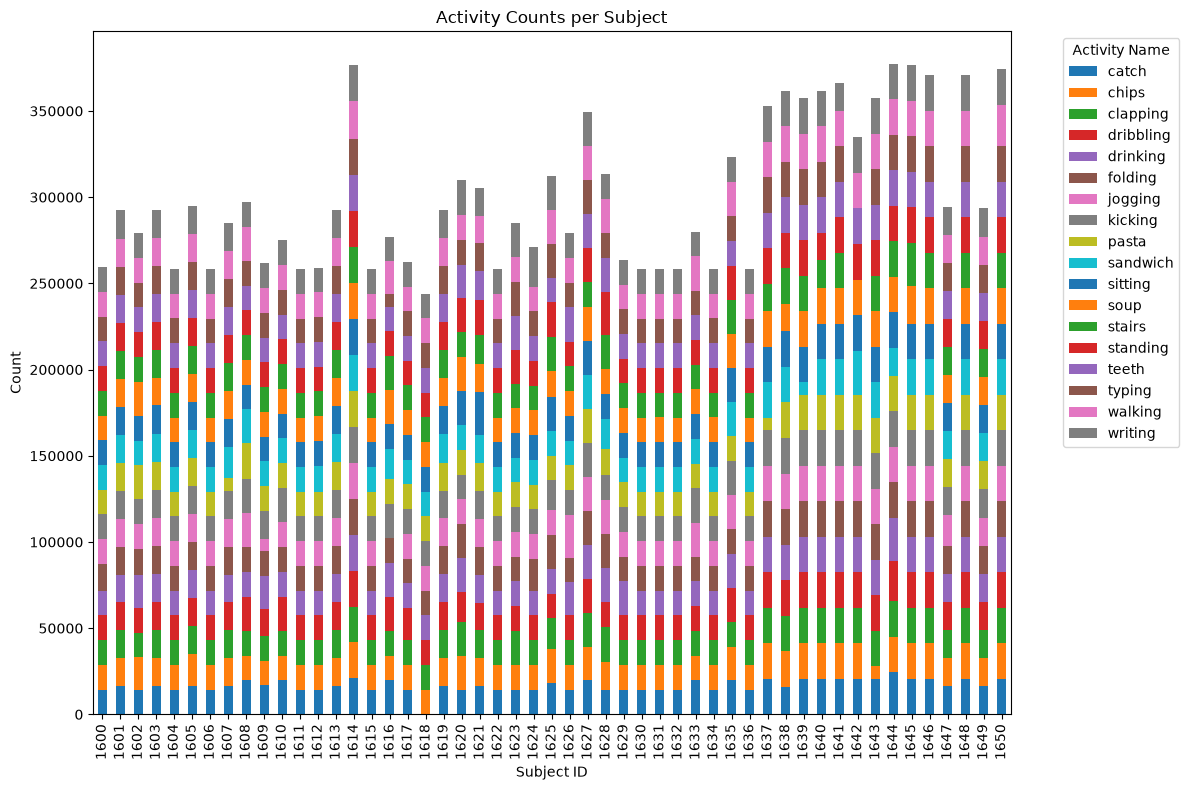

In [8]:
per_subject_activity_counts = (
    df.groupby(["id", "activity_name"], observed=True).size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 8))
per_subject_activity_counts.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("Count")
ax.set_xlabel("Subject ID")
ax.set_title("Activity Counts per Subject")
ax.legend(title="Activity Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis


### 1. Each activity recording is one continuous sequence

For every (device, sensor, subject, activity), all of its rows should form **one continuous block** in `df`:
no other activity's rows in the middle, and the same activity never showing up again later in the same file.
Inside that block, the timestamps should only go up.

A new block starts wherever device, sensor, subject or activity differs from the row above.
If every combination has exactly one block, each recording is a single sequence of that one activity.

In [9]:
block_keys = ["device", "sensor", "id", "activity"]
block_start = df[block_keys].ne(df[block_keys].shift()).any(axis=1)
block_id = block_start.cumsum()

blocks_per_recording = (
    block_id.groupby([df[key] for key in block_keys], observed=True)
    .nunique()
    .rename("blocks")
)
split_recordings = blocks_per_recording[blocks_per_recording > 1]

# inside a block, each timestamp must be larger than the one before it
not_increasing = ~block_start & (df["timestamp"].diff() <= 0)

print(f"recordings (device, sensor, subject, activity): {len(blocks_per_recording):,}")
print(f"recordings split into more than one block:      {len(split_recordings):,}")
print(f"rows where time does not go up inside a block:  {not_increasing.sum():,}")

assert split_recordings.empty, "some recordings are split into several blocks"
assert not not_increasing.any(), "timestamps do not increase inside a block"
print("OK: every recording is a single, time-ordered sequence of one activity")

recordings (device, sensor, subject, activity): 3,637
recordings split into more than one block:      0
rows where time does not go up inside a block:  0
OK: every recording is a single, time-ordered sequence of one activity


The heatmaps show the number of blocks for every subject (columns) and activity (rows), one panel per device and sensor.
A value of **1** means one continuous sequence. A value of **0** (white) means the recording is missing from `df`.

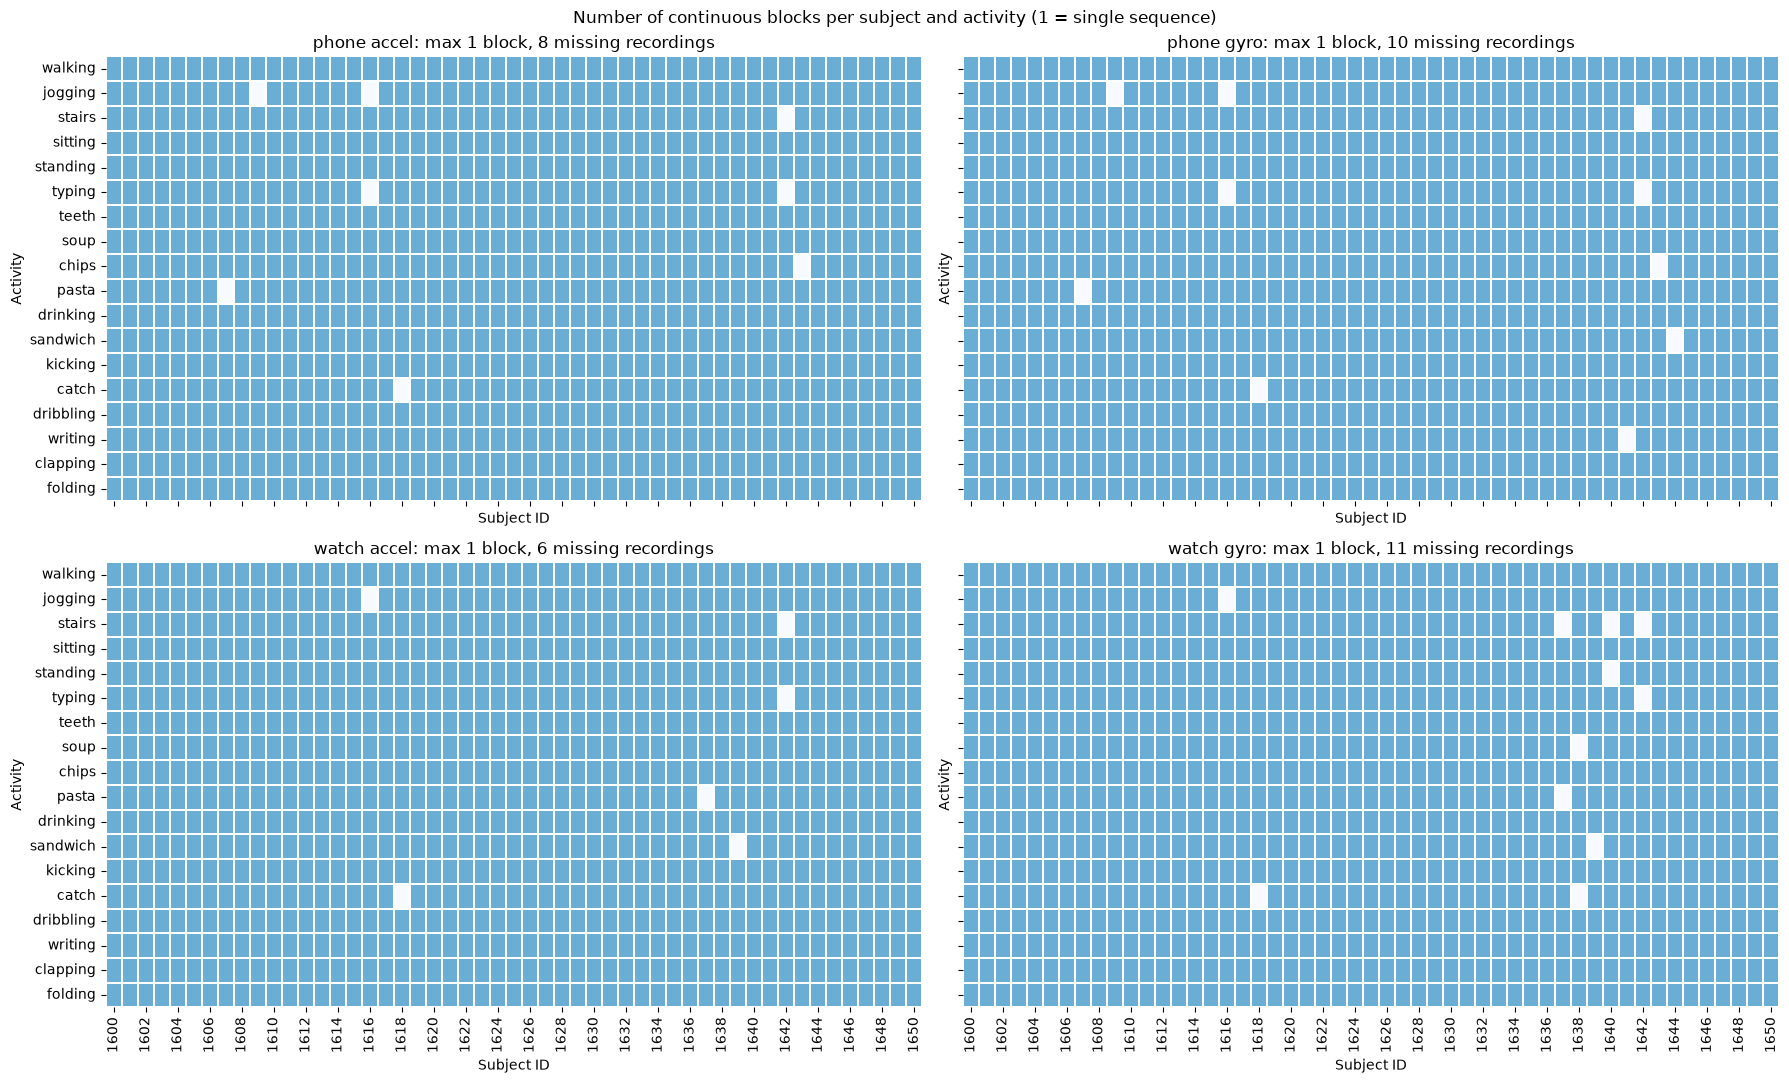

In [10]:
block_counts = blocks_per_recording.reset_index()
block_counts["activity_name"] = block_counts["activity"].map(ACTIVITY_MAP)
subjects = sorted(df["id"].unique())

fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharex=True, sharey=True)
for ax, (device, sensor) in zip(axes.flat, [(d, s) for d in DEVICES for s in SENSORS]):
    grid = (
        block_counts[
            (block_counts["device"] == device) & (block_counts["sensor"] == sensor)
        ]
        .pivot_table(
            index="activity_name", columns="id", values="blocks", aggfunc="sum"
        )
        .reindex(index=list(ACTIVITY_MAP.values()), columns=subjects)
        .fillna(0)
    )
    missing = int((grid == 0).sum().sum())
    sns.heatmap(
        grid,
        cmap="Blues",
        vmin=0,
        vmax=2,
        cbar=False,
        linewidths=0.2,
        linecolor="white",
        ax=ax,
    )
    ax.set_title(
        f"{device} {sensor}: max {int(grid.to_numpy().max())} block, {missing} missing recordings"
    )
    ax.set_xlabel("Subject ID")
    ax.set_ylabel("Activity")
plt.suptitle(
    "Number of continuous blocks per subject and activity (1 = single sequence)"
)
plt.tight_layout()
plt.show()

A timeline for one subject: each row of that subject's data (in file order) plotted against its activity.
Each activity is one flat line, and once an activity ends it never comes back.

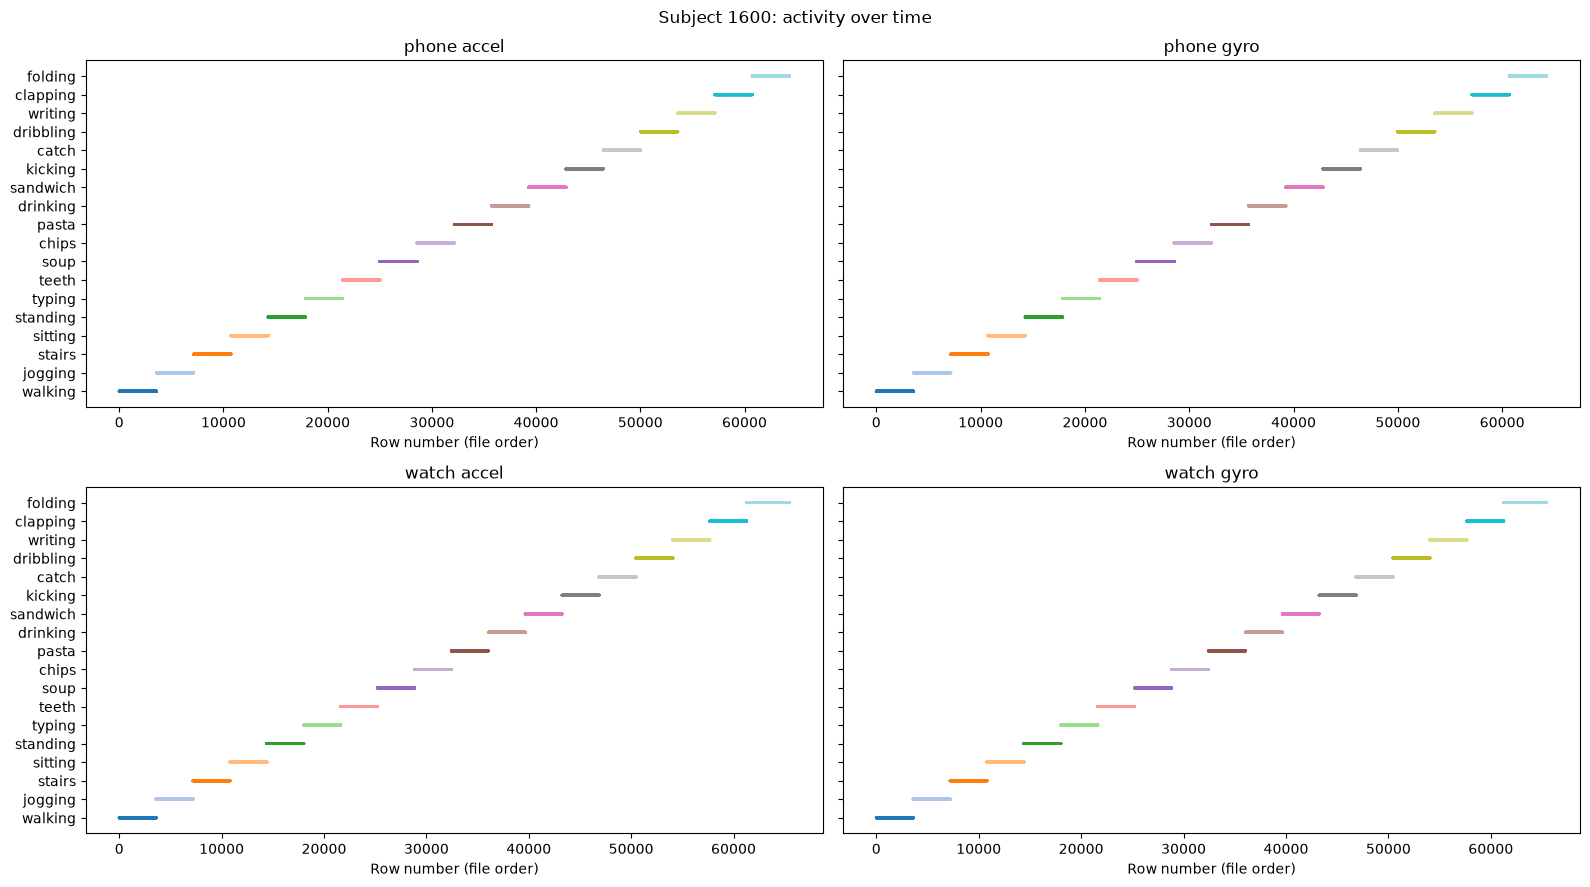

In [11]:
subject = df["id"].min()

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
for ax, (device, sensor) in zip(axes.flat, [(d, s) for d in DEVICES for s in SENSORS]):
    rows = df[
        (df["id"] == subject) & (df["device"] == device) & (df["sensor"] == sensor)
    ]
    row_number = np.arange(len(rows))
    ax.scatter(
        row_number,
        rows["activity_name"].astype(str),
        s=1,
        c=rows["activity"].cat.codes,
        cmap="tab20",
    )
    ax.set_title(f"{device} {sensor}")
    ax.set_xlabel("Row number (file order)")
plt.suptitle(f"Subject {subject}: activity over time")
plt.tight_layout()
plt.show()

### 2. Readings per device and sensor

Count the rows recorded by each of the four sensors (phone/watch × accelerometer/gyroscope).


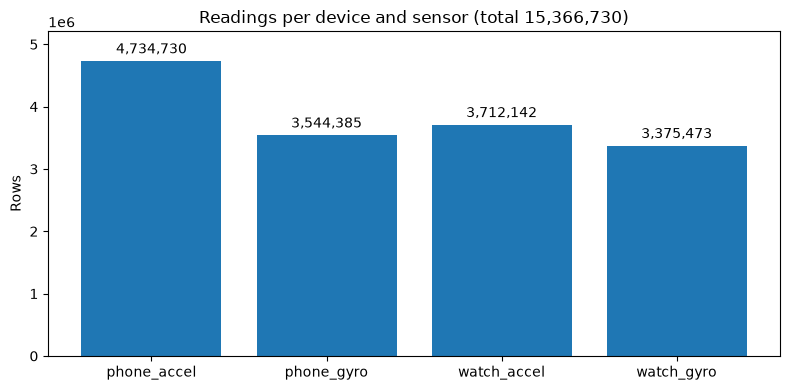

,rows,share_pct
source,,
phone_accel,4734730,30.81
phone_gyro,3544385,23.07
watch_accel,3712142,24.16
watch_gyro,3375473,21.97


In [12]:
df["source"] = (df["device"].astype(str) + "_" + df["sensor"].astype(str)).astype(
    "category"
)

sensor_counts = df.groupby("source", observed=True).size().rename("rows")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    sensor_counts.index.astype(str), sensor_counts.to_numpy(), color="tab:blue"
)
ax.bar_label(bars, labels=[f"{n:,}" for n in sensor_counts], padding=3)
ax.set_ylabel("Rows")
ax.set_title(f"Readings per device and sensor (total {len(df):,})")
ax.margins(y=0.1)
plt.tight_layout()
plt.show()

sensor_counts.to_frame().assign(
    share_pct=lambda t: (t["rows"] / t["rows"].sum() * 100).round(2)
)

### 3. Class balance per activity

Each activity's share of all rows, split by device and sensor.


In [13]:
n_activities = df["activity"].nunique()
balanced_share = 100 / n_activities

activity_source_counts = (
    df.groupby(["activity_name", "source"], observed=True).size().unstack(fill_value=0)
)
activity_share = activity_source_counts.div(len(df)) * 100
activity_share = activity_share.loc[activity_share.sum(axis=1).sort_values().index]
activity_share

source,phone_accel,phone_gyro,watch_accel,watch_gyro
activity_name,,,,
typing,1.579933,1.242756,1.311483,1.194607
pasta,1.602293,1.264264,1.298305,1.210446
stairs,1.640375,1.264342,1.325637,1.150622
sandwich,1.706336,1.264719,1.302027,1.214234
chips,1.677572,1.264654,1.343441,1.226559
jogging,1.723438,1.279921,1.315713,1.198889
catch,1.748238,1.270192,1.343825,1.197919
soup,1.738711,1.293951,1.339660,1.193735
clapping,1.721199,1.293450,1.334890,1.218041


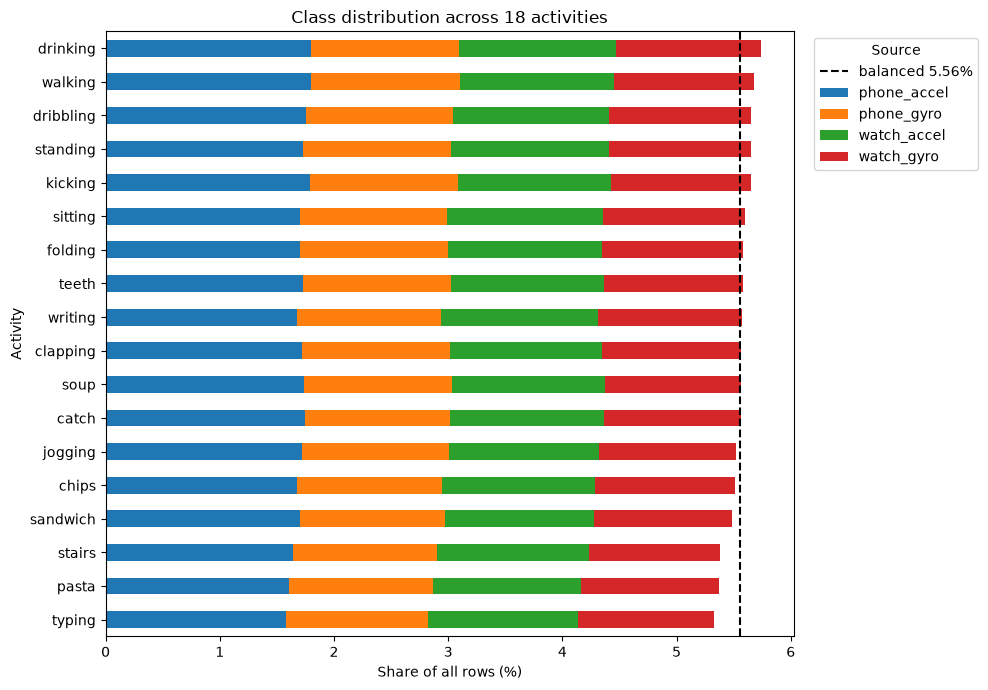

activity_name,drinking,walking,dribbling,standing,kicking,sitting,folding,teeth,writing,clapping,soup,catch,jogging,chips,sandwich,stairs,pasta,typing
class %,5.74,5.68,5.65,5.65,5.65,5.6,5.58,5.58,5.58,5.57,5.57,5.56,5.52,5.51,5.49,5.38,5.38,5.33


In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
activity_share.plot(kind="barh", stacked=True, ax=ax)
ax.axvline(
    balanced_share,
    color="black",
    linestyle="--",
    label=f"balanced {balanced_share:.2f}%",
)
ax.set_xlabel("Share of all rows (%)")
ax.set_ylabel("Activity")
ax.set_title(f"Class distribution across {n_activities} activities")
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

activity_share.sum(axis=1).sort_values(ascending=False).round(2).rename(
    "class %"
).to_frame().T

### 4. Sampling rate

Timestamps are in nanoseconds. The time between two readings in a row is measured inside each
(subject, device, sensor, activity) recording, so jumps between recordings are not counted.
The sampling rate of each sensor


In [15]:
recording_keys = ["id", "device", "sensor", "activity"]
df["dt_ms"] = df.groupby(recording_keys, observed=True)["timestamp"].diff() / 1e6
df.head(5)

,id,activity,timestamp,x,y,z,sensor,device,activity_name,source,dt_ms
0,1600,A,252207666810782,-0.364761,8.793503,1.055084,accel,phone,walking,phone_accel,NaN
1,1600,A,252207717164786,-0.879730,9.768784,1.016998,accel,phone,walking,phone_accel,50.354004
2,1600,A,252207767518790,2.001495,11.109070,2.619156,accel,phone,walking,phone_accel,50.354004
3,1600,A,252207817872794,0.450623,12.651642,0.184555,accel,phone,walking,phone_accel,50.354004
4,1600,A,252207868226798,-2.164352,13.928436,-4.422485,accel,phone,walking,phone_accel,50.354004


In [16]:
dt_summary = df.groupby("source", observed=True)["dt_ms"].describe(
    percentiles=[0.05, 0.5, 0.95]
)
dt_summary

,count,mean,std,min,5%,50%,95%,max
source,,,,,,,,
phone_accel,4733820.0,34.593225,14.010571,1.627864,20.096,39.686565,50.354004,255.952663
phone_gyro,3543477.0,46.062220,5.318732,1.634167,39.563,50.354003,50.354004,255.952663
watch_accel,3711230.0,44.249876,45.965305,2.509000,20.096,49.923550,49.988870,56655.903353
watch_gyro,3374566.0,48.372556,46.907122,8.332567,40.297,49.925380,49.989830,56655.903353


In [17]:
dt_summary["rate_hz"] = 1000 / dt_summary["50%"]
SAMPLE_RATE_HZ = dt_summary["rate_hz"].to_dict()
dt_summary

,count,mean,std,min,5%,50%,95%,max,rate_hz
source,,,,,,,,,
phone_accel,4733820.0,34.593225,14.010571,1.627864,20.096,39.686565,50.354004,255.952663,25.197444
phone_gyro,3543477.0,46.062220,5.318732,1.634167,39.563,50.354003,50.354004,255.952663,19.859394
watch_accel,3711230.0,44.249876,45.965305,2.509000,20.096,49.923550,49.988870,56655.903353,20.030627
watch_gyro,3374566.0,48.372556,46.907122,8.332567,40.297,49.925380,49.989830,56655.903353,20.029893


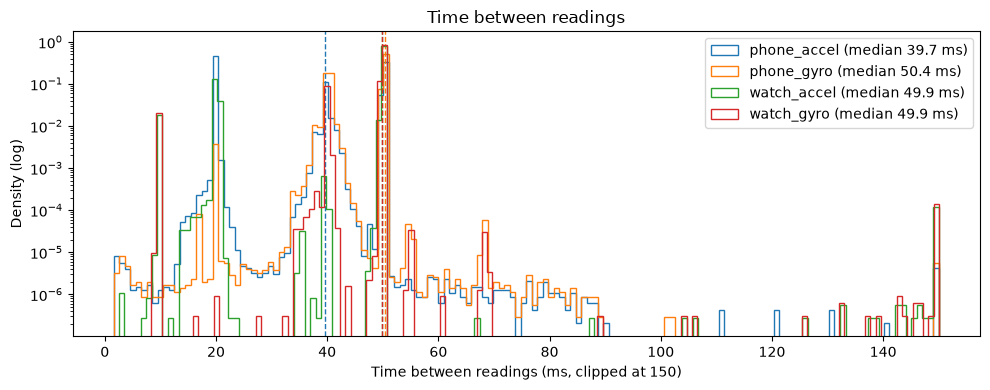

,count,5%,50%,95%,max,rate_hz
source,,,,,,
phone_accel,4733820.0,20.10,39.69,50.35,255.95,25.20
phone_gyro,3543477.0,39.56,50.35,50.35,255.95,19.86
watch_accel,3711230.0,20.10,49.92,49.99,56655.90,20.03
watch_gyro,3374566.0,40.30,49.93,49.99,56655.90,20.03


In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
for (source, group), color in zip(
    df.groupby("source", observed=True), plt.cm.tab10.colors
):
    ax.hist(
        group["dt_ms"].dropna().clip(0, 150),
        bins=150,
        histtype="step",
        density=True,
        color=color,
        label=f"{source} (median {dt_summary.loc[source, '50%']:.1f} ms)",
    )
    ax.axvline(dt_summary.loc[source, "50%"], color=color, linestyle="--", linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("Time between readings (ms, clipped at 150)")
ax.set_ylabel("Density (log)")
ax.set_title("Time between readings")
ax.legend()
plt.tight_layout()
plt.show()

dt_summary[["count", "5%", "50%", "95%", "max", "rate_hz"]].round(2)

### 5. Recording length

The length of each (subject, sensor, activity) recording is last timestamp − first timestamp.
Using timestamps instead of row counts means sensors with different sampling rates can be compared directly.


In [19]:
recording_minutes = (
    df.groupby(recording_keys, observed=True)["timestamp"]
    .agg(lambda t: (t.max() - t.min()) / 1e9 / 60)
    .rename("minutes")
    .reset_index()
)
recording_minutes["source"] = (
    recording_minutes["device"].astype(str)
    + "_"
    + recording_minutes["sensor"].astype(str)
)
recording_minutes

,id,device,sensor,activity,minutes,source
0,1600,phone,accel,A,2.998581,phone_accel
1,1600,phone,accel,B,2.996902,phone_accel
2,1600,phone,accel,C,2.997741,phone_accel
3,1600,phone,accel,D,2.996903,phone_accel
4,1600,phone,accel,E,2.996902,phone_accel
...,...,...,...,...,...,...
3632,1650,watch,gyro,O,2.995802,watch_gyro
3633,1650,watch,gyro,P,2.995240,watch_gyro
3634,1650,watch,gyro,Q,2.995377,watch_gyro
3635,1650,watch,gyro,R,2.995450,watch_gyro


In [20]:
median_recording = recording_minutes["minutes"].median()
median_recording

np.float64(2.997455616666667)

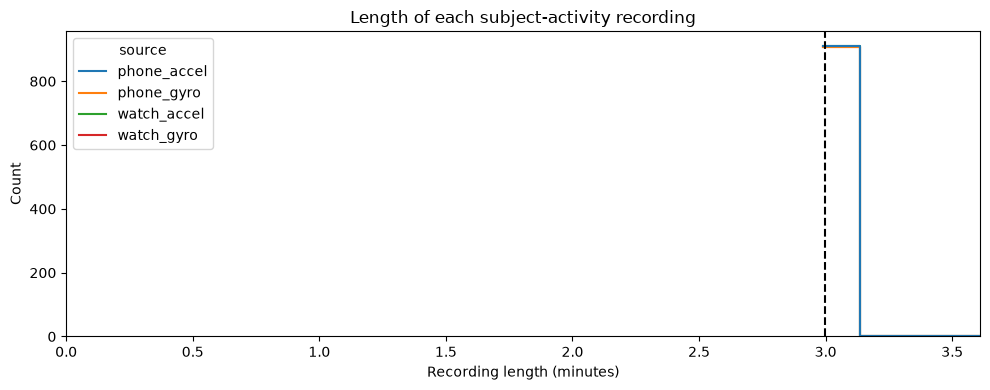

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
phone_accel,910.0,3.0,0.00,2.99,3.00,3.0,3.0,3.02
phone_gyro,908.0,3.0,0.00,2.99,2.99,3.0,3.0,3.00
watch_accel,912.0,3.0,0.09,3.00,3.00,3.0,3.0,5.86
watch_gyro,907.0,3.0,0.09,2.99,3.00,3.0,3.0,5.85


In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(
    data=recording_minutes,
    x="minutes",
    hue="source",
    bins=20,
    element="step",
    fill=False,
    ax=ax,
)
ax.axvline(
    median_recording,
    color="black",
    linestyle="--",
    label=f"median {median_recording:.2f} min",
)
ax.set_xlim(0, recording_minutes["minutes"].quantile(0.99) * 1.2)
ax.set_xlabel("Recording length (minutes)")
ax.set_title("Length of each subject-activity recording")
plt.tight_layout()
plt.show()

recording_minutes.groupby("source")["minutes"].describe().round(2)

Total minutes per subject and sensor (sum of that subject's recordings).
The color scale is centered on the median across all subjects, so cells far from the median stand out.


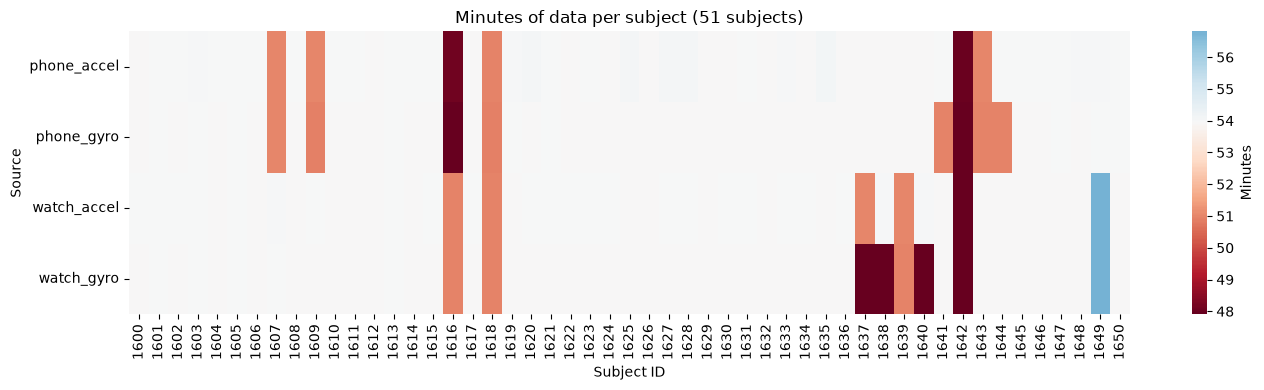

In [22]:
minutes_per_subject = recording_minutes.pivot_table(
    index="source", columns="id", values="minutes", aggfunc="sum"
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    minutes_per_subject,
    cmap="RdBu",
    center=np.nanmedian(minutes_per_subject.to_numpy()),
    cbar_kws={"label": "Minutes"},
    ax=ax,
)
ax.set_xlabel("Subject ID")
ax.set_ylabel("Source")
ax.set_title(f"Minutes of data per subject ({df['id'].nunique()} subjects)")
plt.tight_layout()
plt.show()

### 6. Value distributions of x, y and z

Accelerometer values are in m/s², gyroscope values in rad/s.


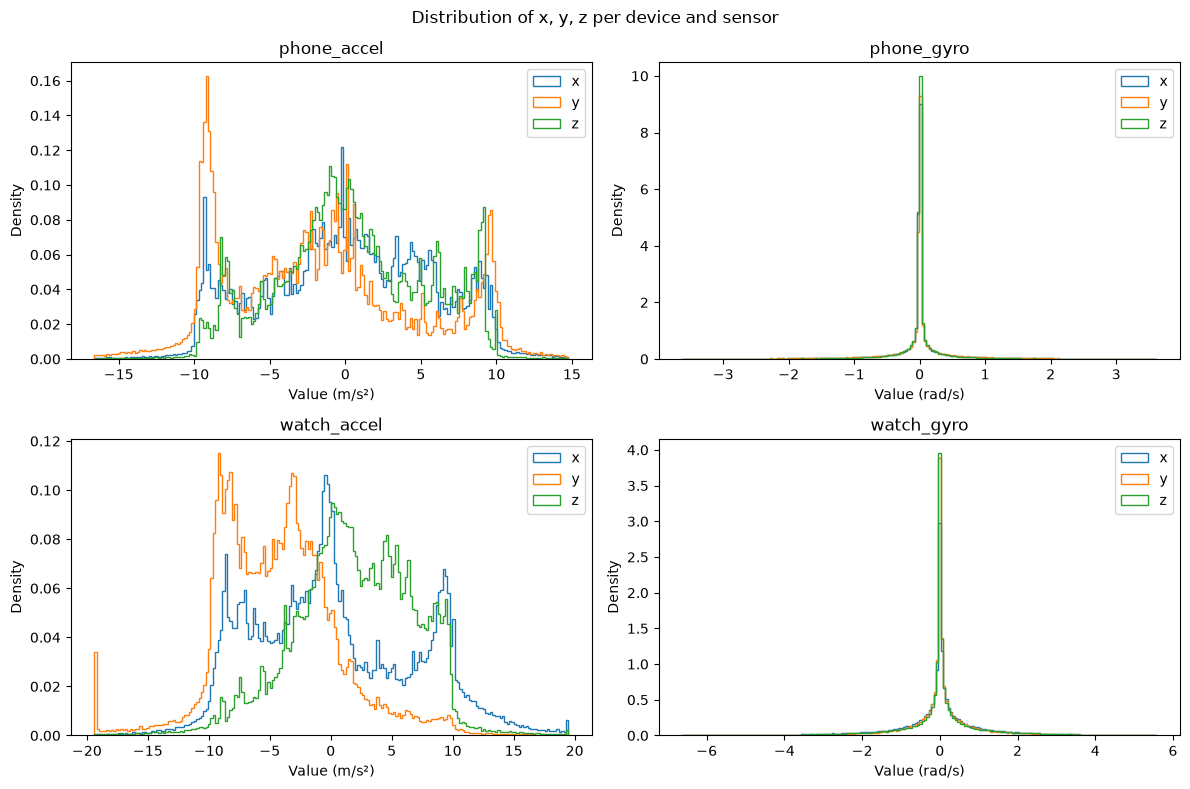

x                                 y                   \
             mean   std        min        max  mean   std        min   
source                                                                 
phone_accel  0.17  5.86 -65.779999  75.029999 -1.75  6.87 -66.820000   
phone_gyro  -0.01  0.86 -18.290001  20.090000 -0.00  0.96 -22.959999   
watch_accel  0.37  6.95 -43.790001  39.720001 -4.45  5.36 -62.060001   
watch_gyro  -0.02  1.59 -26.370001  33.230000 -0.03  1.49 -34.900002   

                           z                              
                   max  mean   std        min        max  
source                                                    
phone_accel  33.720001  0.38  5.11 -59.580002  69.080002  
phone_gyro   20.070000 -0.00  0.66 -22.000000  10.540000  
watch_accel  23.139999  1.89  5.24 -57.240002  53.820000  
watch_gyro   22.570000  0.01  1.40 -20.740000  16.650000

In [23]:
sample = df.sample(500_000, random_state=42)  # taking a random sample of 500,000 rows

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (source, group) in zip(axes.flat, sample.groupby("source", observed=True)):
    values = group[["x", "y", "z"]]
    low, high = np.nanpercentile(values.to_numpy(), [0.5, 99.5])
    for axis in ["x", "y", "z"]:
        ax.hist(
            values[axis],
            bins=200,
            range=(low, high),
            histtype="step",
            label=axis,
            density=True,
        )
    unit = "m/s²" if "accel" in source else "rad/s"
    ax.set_title(source)
    ax.set_xlabel(f"Value ({unit})")
    ax.set_ylabel("Density")
    ax.legend()
plt.suptitle("Distribution of x, y, z per device and sensor")
plt.tight_layout()
plt.show()

sample.groupby("source", observed=True)[["x", "y", "z"]].agg(
    ["mean", "std", "min", "max"]
).round(2)

### 7. Signal magnitude per activity

The magnitude √(x² + y² + z²) does not depend on how the device is turned.
The dashed accelerometer line is the median magnitude while _sitting_, measured from `df`, which is roughly the value of a still device (gravity only).


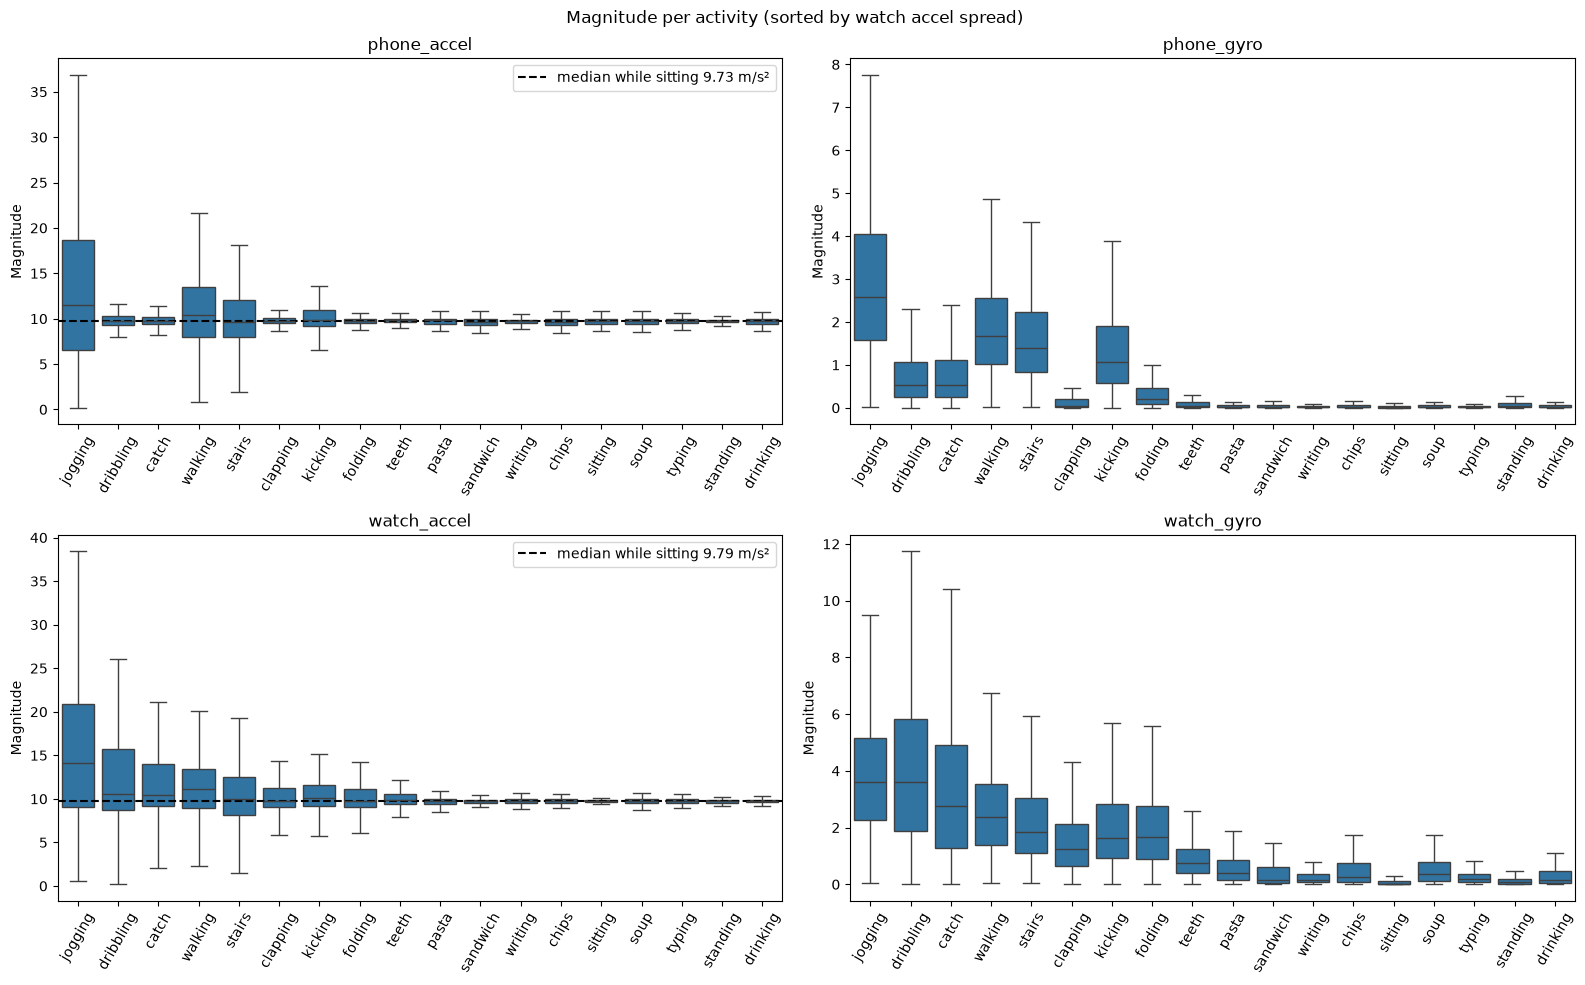

In [24]:
sample["magnitude"] = np.sqrt(sample["x"] ** 2 + sample["y"] ** 2 + sample["z"] ** 2)
resting_magnitude = (
    sample[sample["activity_name"] == "sitting"]
    .groupby("source", observed=True)["magnitude"]
    .median()
)
activity_order = (
    sample[sample["source"] == "watch_accel"]
    .groupby("activity_name", observed=True)["magnitude"]
    .std()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (source, group) in zip(axes.flat, sample.groupby("source", observed=True)):
    sns.boxplot(
        data=group,
        x="activity_name",
        y="magnitude",
        order=activity_order,
        showfliers=False,
        ax=ax,
        color="tab:blue",
    )
    if "accel" in source:
        ax.axhline(
            resting_magnitude[source],
            color="black",
            linestyle="--",
            label=f"median while sitting {resting_magnitude[source]:.2f} m/s²",
        )
        ax.legend()
    ax.set_title(source)
    ax.set_xlabel("")
    ax.set_ylabel("Magnitude")
    ax.tick_params(axis="x", rotation=60)
plt.suptitle("Magnitude per activity (sorted by watch accel spread)")
plt.tight_layout()
plt.show()

### 8. Example 10-second windows

The PDF cuts the signal into 10-second windows to make labeled examples.
Below is one 10-second window of watch accelerometer data from the first subject in `df` for a few activities.
The window is picked by timestamp, so it is 10 seconds long whatever the sensor's sampling rate.


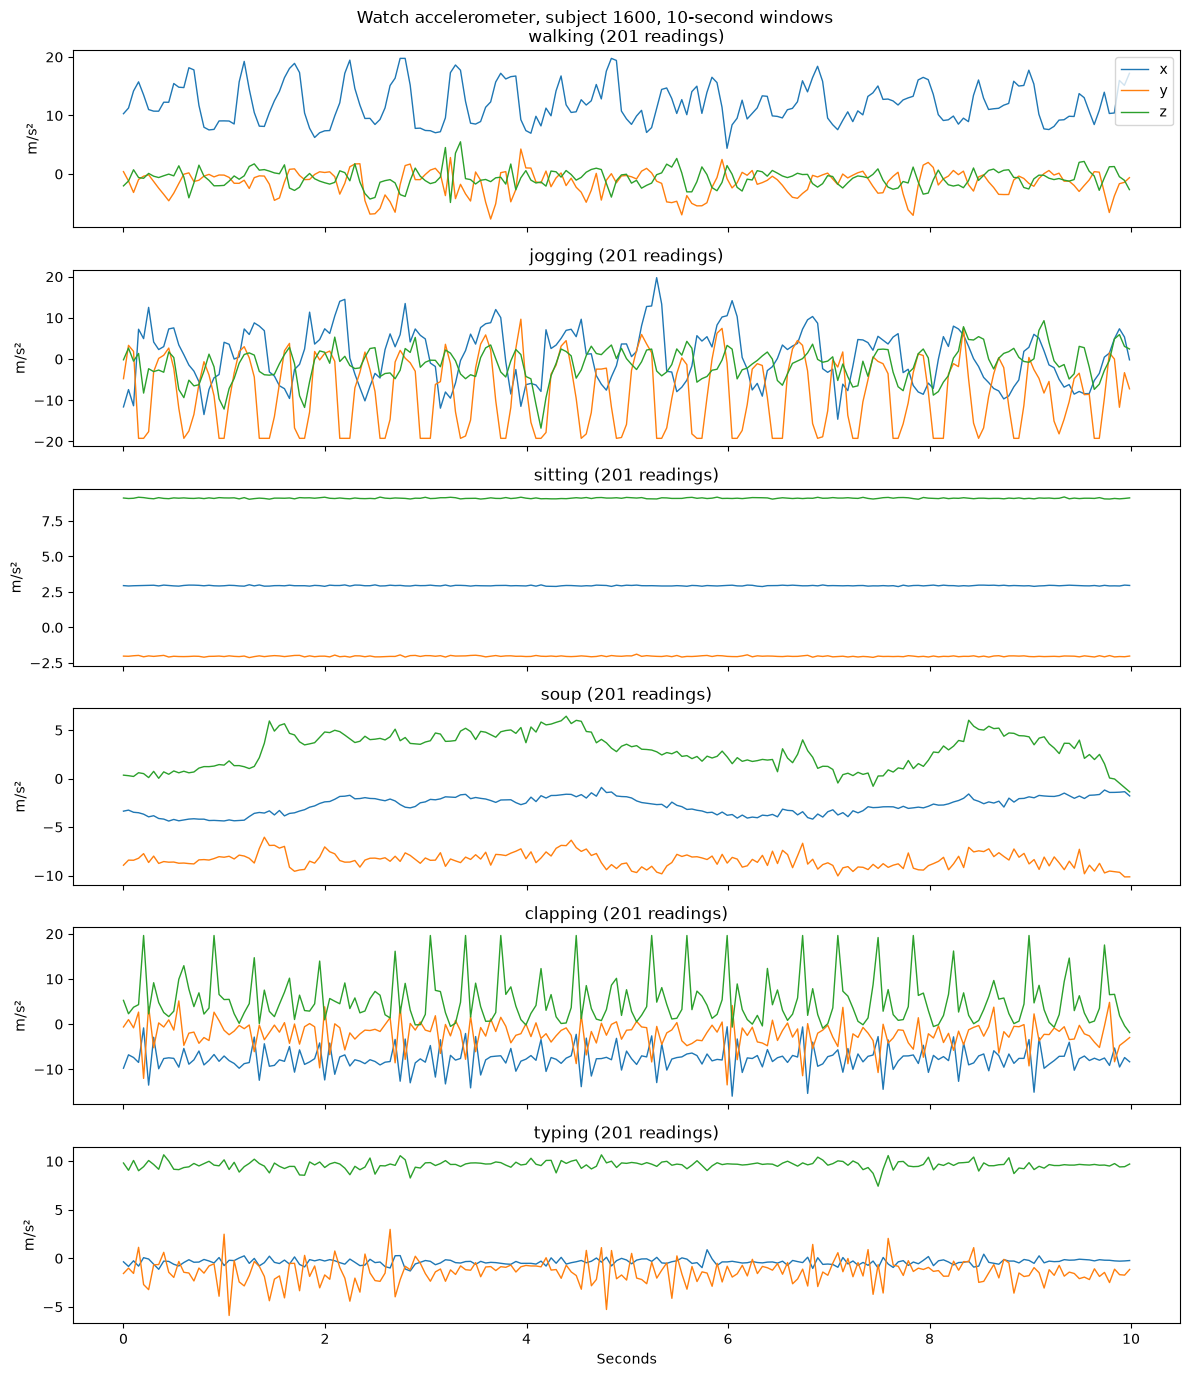

In [25]:
WINDOW_SECONDS = 10
example_activities = ["walking", "jogging", "sitting", "soup", "clapping", "typing"]
subject = df["id"].min()

fig, axes = plt.subplots(len(example_activities), 1, figsize=(12, 14), sharex=True)
for ax, activity in zip(axes, example_activities):
    recording = df[
        (df["id"] == subject)
        & (df["source"] == "watch_accel")
        & (df["activity_name"] == activity)
    ].sort_values("timestamp")
    seconds = (
        recording["timestamp"] - recording["timestamp"].iloc[len(recording) // 2]
    ) / 1e9
    window = recording[(seconds >= 0) & (seconds < WINDOW_SECONDS)]
    for axis in ["x", "y", "z"]:
        ax.plot(seconds[window.index], window[axis].to_numpy(), label=axis, linewidth=1)
    ax.set_title(f"{activity} ({len(window)} readings)")
    ax.set_ylabel("m/s²")
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Seconds")
plt.suptitle(f"Watch accelerometer, subject {subject}, {WINDOW_SECONDS}-second windows")
plt.tight_layout()
plt.show()